## Notebook for Named Entity Recognition based on GliNER


## 1) Data loading and libraries

In [1]:
# Final entity types (for now) until 11.3.2025.

# FET = """Ecosystem
# Energy Source
# Natural Disaster
# Meteorological Phenomenon
# Quantity
# Astronomical Object
# Body of Water
# Disease
# Location
# Measurement Unit
# Physical Phenomenon
# Chemical
# Time Period
# Organization
# Natural Phenomenon
# Field of Study
# Mathematical Expression
# Measuring Device
# Geographical Feature
# System
# Satellite"""

# Final entity types

# FET = """Ecosystem
# Energy Source
# Natural Disaster
# Meteorological Phenomenon
# Quantity
# Astronomical Object
# Body of Water
# Disease
# Location
# Physical Phenomenon
# Chemical
# Time Period
# Organization
# Natural Phenomenon
# Field of Study
# Mathematical Expression
# Measuring Device
# Geographical Feature
# System
# Satellite
# Organism
# Method
# Other"""

# FET = """Ecosystem
# Energy Source
# Natural Disaster
# Meteorological Phenomenon
# Quantity
# Astronomical Object
# Body of Water
# Disease
# Location
# Physical Phenomenon
# Chemical
# Time Period
# Organization
# Natural Phenomenon
# Field of Study
# Mathematical Expression
# Measuring Device
# Geographical Feature
# System
# Satellite
# Organism
# Method
# Other
# Person
# Artefact
# Body Part
# Symptom"""

# Final entity types (for now) from 30.10.2025.

FET = """Asset
Body Part
Body of Water
Chemical
Disease
Ecosystem
Energy Source
Field of Study
Geographical Feature
Intellectual Artefact
Location
Mathematical Expression
Measuring Device
Meteorological Phenomenon
Method
Natural Disaster
Natural Phenomenon
Organism
Organization
Other
Person
Physical Artefact
Physical Phenomenon
Policy
Quantity
Satellite
System
Time Period
"""

IBMCCNER_LABELS = list({
    "climate-assets", "climate-datasets", "climate-greenhouse-gases",     
    "climate-hazards", "climate-impacts", "climate-mitigations",     
    "climate-models", "climate-nature", "climate-observations",     
    "climate-organisms", "climate-organizations", "climate-problem-origins",
    "climate-properties"
})


In [2]:
from seqeval.metrics.sequence_labeling import get_entities # This is for some reason neccessary for rest of the library loading??

from pspf import *
from random import sample, seed
from gliner import GLiNER
from tqdm import tqdm
import json
from os import listdir
# import matplotlib.pyplot as plt
# import seaborn as sns



c:\Users\Desktop\.conda\envs\gliner_finetune\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
PAPER_DIR = "./DATA/V1_PSS" # PC2 - GLiNER_IBMCCNER_P # "./DATA/PAPERS_SENTENCES"  # "./DATA/PAPERS_SENTENCES_20K_SAMPLE" #20K 12.3.2025. # "./DATA/PAPERS_SENTENCES_SAMPLE" # "./PAPERS_SENTENCES_SAMPLE" # PC2

papers = load_paper_names(PAPER_DIR)

seed(3012)

test_papers = papers
print(test_papers[:5])
print(len(test_papers))

['10061_Effect_of_Na_Doping_on_the_Electrochemical_Performance_of_Li1.2Ni0.13Co0.13Mn0.54O2_Cathode_for_Lithium-Ion_Batteries.txt', '10167_Clinical_Observations_Associated_with_Phenobarbital_Serum_Monitoring_to_Manage_Epilepsy_in_a_California_Sea_Lion_with_Domoic_Acid_Toxicosis.txt', '10662_Design_and_Implementation_of_a_Smart_Lithium-Ion_Battery_System_with_Real-Time_Fault_Diagnosis_Capability_for_Electric_Vehicles.txt', '1072_Spatiotemporal_climate_variability_in_the_Andes_of_northern_Peru__Evaluation_of_gridded_datasets_to_describe_cloud_forest_microclimate_and_local_rainfall.txt', '10756_Air_Pollution_Tolerance_Index_and_Heavy_Metals_Accumulation_of_Tree_Species_for_Sustainable_Environmental_Management_in_Megacity_of_Lahore.txt']
50


In [4]:
# Functions

RESULT_DIR = "./RESULTS/GLINER_MEDIUM_V25_V1_PSS/"
"./RESULTS/GLINER_IBMCCNER_P_50P_SAMPLE/" # Annotations from GLiNER IBMCCNER fine-tuned model
# "./RESULTS/GLINER_TESTS_FULL_27/" # "./RESULTS/GLINER_TESTS_20K/" # "./DATA/RESULTS/GLINER_TESTS/" # "./RESULTS/GLINER_TESTS/" # (PC2)

def dict2json(dict_data, title="unnamed", threshold="undefined"):
    """
    Save a dictionary to a JSON file with a specified filename format.

    Parameters:
    - dict_data (dict): The dictionary to save.
    - title (str, optional): A descriptive title for the file. Defaults to "unnamed".
    - threshold (str or float, optional): A threshold value used in the filename. Defaults to "undefined".

    The resulting filename will follow the pattern `{threshold*100}_{title}.json`, 
    and the file will be saved in the directory specified by `RESULT_DIR`.
    """
    
    # Save the data to a JSON file
    try:
        with open(RESULT_DIR + f'{int(threshold*100)}_{title}.json', 'w') as f:
            json.dump(dict_data, f, indent=4)
    except OSError:
        print("Name too long or invalid, shortening ...")
        short_title = "".join(title.split("_")[:5])
        with open(RESULT_DIR + f'{int(threshold*100)}_{short_title}.json', 'w') as f:
            json.dump(dict_data, f, indent=4)
        
def json2dict(json_file, RESULT_DIR = RESULT_DIR):
    """
    Load a dictionary from a JSON file and extract metadata from the filename.

    Parameters:
    - json_file (str): The name of the JSON file to load. Assumes the filename 
      follows the pattern `{threshold}_{title}.json`.

    Returns:
    - loaded_data (dict): The loaded dictionary from the JSON file.
    - thr (str): The threshold value extracted from the filename.
    - title (str): The title extracted from the filename.
    """
    
    # Load the data from the JSON file
    with open(RESULT_DIR + json_file, 'r') as f:
        loaded_data = json.load(f)
        
    thr = json_file.split("_")[0]
    title = json_file[len(thr)+1:].replace(".json", "")
    
    return loaded_data, thr, title


## 2) Model loading

In [5]:
# Initialize GLiNER with the base model
# model = GLiNER.from_pretrained("urchade/gliner_medium-v2.1") # Original annotation
# model = GLiNER.from_pretrained("GLINER/models/GLiNER_med_v2_1/IBMCCNER_PURE/checkpoint-462", load_tokenizer=True) # Fine-tuned only on Climate-Change-NER (IBM)
model = GLiNER.from_pretrained("gliner-community/gliner_medium-v2.5", load_tokenizer=True) # From now on using v2.5 as it shows minor improvement
# Labels for entity prediction
# Most GLiNER models should work best when entity types are in lower case or title case
labels = FET.split("\n")
# labels = IBMCCNER_LABELS

print(f"Labels ({len(labels)}): ", labels)

Fetching 10 files: 100%|██████████| 10/10 [01:49<00:00, 10.95s/it]


Labels (29):  ['Asset', 'Body Part', 'Body of Water', 'Chemical', 'Disease', 'Ecosystem', 'Energy Source', 'Field of Study', 'Geographical Feature', 'Intellectual Artefact', 'Location', 'Mathematical Expression', 'Measuring Device', 'Meteorological Phenomenon', 'Method', 'Natural Disaster', 'Natural Phenomenon', 'Organism', 'Organization', 'Other', 'Person', 'Physical Artefact', 'Physical Phenomenon', 'Policy', 'Quantity', 'Satellite', 'System', 'Time Period', '']


## 3) Model inference

### 3.1) For preview

In [ ]:
tps_e = [] # Test paper sentences with entities
for paper in tqdm(test_papers):
    
    test_paper_sentences = load_paper_sentences(paper, PAPER_DIR)
    
    for text in tqdm(test_paper_sentences):
        print("Sentence: ", text)
        print("---"*10)
        # Perform entity prediction
        entities = model.predict_entities(text, labels, threshold=0.33)

        # Display predicted entities and their labels
        for entity in entities:
            print(entity["text"], "=>", entity["label"])

        tps_e.append({"sentence": text, "entities":entities})
        print("---"*10)
        print("---"*10)
        break

### 3.2) Model inference for real

In [8]:
THRESHOLDS = [0.05, 0.10, 0.20, 0.25, 0.30, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.80, 0.90, 0.95]
thr = 0.05
DONE = listdir(RESULT_DIR)
for paper in tqdm(test_papers):
    # print(paper)
    # print(paper)
    if "5_" + paper.replace(".txt", ".json") in DONE:
        continue
    # print(paper)
    # Load sentences

    paper_sentences = load_paper_sentences(paper, PAPER_DIR)
    
    # List of tagged sentences
    paper_dict = []
    
    for s_id, text in enumerate(paper_sentences):
        if len(text) > 3 and text != "no_content":
            # print(text)
            try:
                entities = model.predict_entities(text, labels, threshold=thr)
                paper_dict.append({"sentence_id": s_id, "sentence": text, "entities":entities})
            except IndexError:
                paper_dict.append({"sentence_id": s_id, "sentence": text, "entities":entities})
        else:
            paper_dict.append({"sentence_id": s_id, "sentence": text, "entities": "no_entities"})
    
    dict2json(paper_dict, paper.replace(".txt", ""), thr)

        
    

  4%|▍         | 2/50 [00:46<17:55, 22.40s/it]

In [ ]:
import os
print(os.path.exists("./PAPERS_SENTENCES_SAMPLE/116559_Phylogenetic_relationships_among_domesticated_and_wild_species_of_Cucurbita_(Cucurbitaceae)_inferred_from_a_mitochondrial_gene_Implications_for_crop_plant_evolution_and_areas_of_origin.txt"))


In [ ]:
loaded_data, _, _ = json2dict("50_106710_Pancreatic_islet_amyloidosis,_β-cell_apoptosis,_and_α-cell_proliferation_are_determinants_of_islet_remodeling_in_type-2_diabetic_baboons.json")
assert paper_dict == loaded_data

##

In [19]:
# THRESHOLDS = [0.05, 0.10, 0.20, 0.25, 0.30, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.80, 0.90, 0.95]
THR = 0

## 4) Resulting annotation analysis

In [13]:
# Functions
from os import listdir
from random import sample


RESULT_DIR = "./RESULTS/GLINER_IBMCCNER_P_50P_SAMPLE/" # "./RESULTS/GLINER_TESTS/" # PC2

# test_files = sample(listdir(RESULT_DIR), 10)
test_files = listdir(RESULT_DIR)

print(len(test_files))

50


In [21]:
# 00:05:46 for 31093


import pandas as pd
from tqdm import tqdm

columns = ["paper_id", "sentence_id", "sentence"]
columns.extend(labels)
print(columns)
entity_matrix = pd.DataFrame(columns=columns)


# Initialize the DataFrame
rows = []



for test_file in tqdm(test_files):
    try:
        data_p, thr_p, title_p = json2dict(test_file)
        
        paper_id = title_p.split("_")[0]
        
        # Process the JSON data
        for item in data_p:
            sentence_id = item["sentence_id"]
            sentence = item["sentence"]
            
            # Initialize a row with empty lists for entity occurrences
            row = {col: [] for col in columns}
            row['paper_id'] = paper_id
            row['sentence_id'] = sentence_id
            row['sentence'] = sentence
            
            # Collect occurrences of each entity label
            for entity in item.get("entities", []):
                if isinstance(entity, dict) and entity.get("score", 0) >= THR:
                    label = entity["label"]
                    if label in row:
                        row[label].append(entity["text"])  # Add the entity's text to the list
            
            rows.append(row)
    except:
        print(f"FIle ({test_file}) not found, skipping ...")

# Create the DataFrame
df_og = pd.DataFrame(rows, columns=columns)

MATRICES_DIR = "./RESULTS/GLINER_TESTS_MATRICES/"
# Save the DataFrame
# df_og.to_csv(MATRICES_DIR + f"{int(THR*100)}_" + "matrix_occurance" +".csv")

# Define a function to calculate the length of a list
def list_length(cell):
    if isinstance(cell, list):  # Ensure we only process lists
        return len(cell)
    return cell  # Return the cell as-is if it's not a list

# Apply the function to all cells in the DataFrame
df_counts = df_og.map(list_length)
# df_counts.to_csv(MATRICES_DIR + f"{int(THR*100)}_" + "matrix_frequency" +".csv")

['paper_id', 'sentence_id', 'sentence', 'climate-organisms', 'climate-mitigations', 'climate-greenhouse-gases', 'climate-impacts', 'climate-models', 'climate-nature', 'climate-observations', 'climate-problem-origins', 'climate-properties', 'climate-hazards', 'climate-datasets', 'climate-organizations', 'climate-assets']


100%|██████████| 50/50 [00:00<00:00, 155.54it/s]


In [15]:
import pandas as pd

df = df_og.copy()

# Assuming your DataFrame is named df
col1 = "Natural Phenomenon"
col2 = "Meteorological Phenomenon"

# Convert string representations of lists to actual lists (if needed)
df[col1] = df[col1].apply(eval) if isinstance(df[col1].iloc[0], str) else df[col1]
df[col2] = df[col2].apply(eval) if isinstance(df[col2].iloc[0], str) else df[col2]

# Flatten both columns into unique sets of entities
entities_col1 = set(entity for sublist in df[col1] for entity in sublist)
entities_col2 = set(entity for sublist in df[col2] for entity in sublist)

# Find the overlap (common entities)
common_entities = entities_col1 & entities_col2

# Output results
print(f"Total unique {col1} entities: {len(entities_col1)}")
print(f"Total unique {col2} entities: {len(entities_col2)}")
print(f"Number of unique overlapping entities: {len(common_entities)}")
print("\nSample of overlapping entities:")
print(list(common_entities)[:10])  # Show first 10 overlapping entities

print(df[df["overlap"].apply(lambda x: len(x) > 0)][["sentence", col1, col2, "overlap"]].head(10))


KeyError: 'Natural Phenomenon'

#### Distribution of Entity Counts per Sentence (DECS)

Basic Statistics about Entity Count per Sentence:
count    14205.000000
mean         7.242943
std          5.553411
min          0.000000
25%          3.000000
50%          7.000000
75%         10.000000
max         91.000000
Name: entity_count, dtype: float64


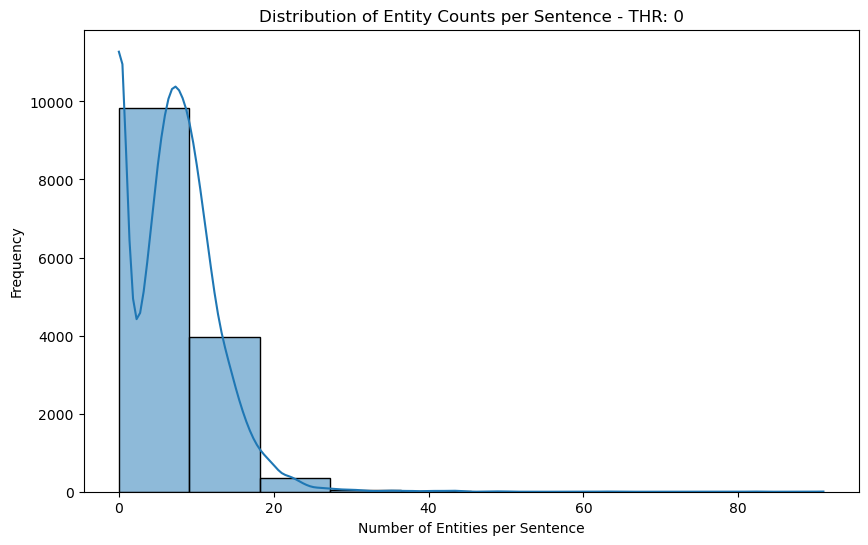

In [22]:
# 00:00:54 for 31093


import matplotlib.pyplot as plt
import seaborn as sns

df = df_og.copy()


# Apply the function to all cells in the DataFrame
df_counts = df.map(list_length)

# Get the total count of entities per sentence by summing values across all entity columns
df_counts['entity_count'] = df_counts.iloc[:, 3:].sum(axis=1)

# Print basic statistics about the entity count
print("Basic Statistics about Entity Count per Sentence:")
print(df_counts['entity_count'].describe())

# Plot the distribution of entity counts per sentence
plt.figure(figsize=(10, 6))
sns.histplot(df_counts['entity_count'], kde=True, bins=10)
plt.title(f"Distribution of Entity Counts per Sentence - THR: {THR}")

# plt.ylim(0, 1200)
# plt.xlim(0, 40)

plt.xlabel("Number of Entities per Sentence")
plt.ylabel("Frequency")
# Save the plot to a specific location
output_path = f"./RESULTS/GLINER_TESTS_PLOTS/DECS_{int(THR*100)}_{len(df_counts)}.png"  # Change to your desired path
plt.savefig(output_path, dpi=300, bbox_inches="tight")  # Save with high resolution and tight layout
plt.show()

#### Total Count of Entities per Label (TCEL)

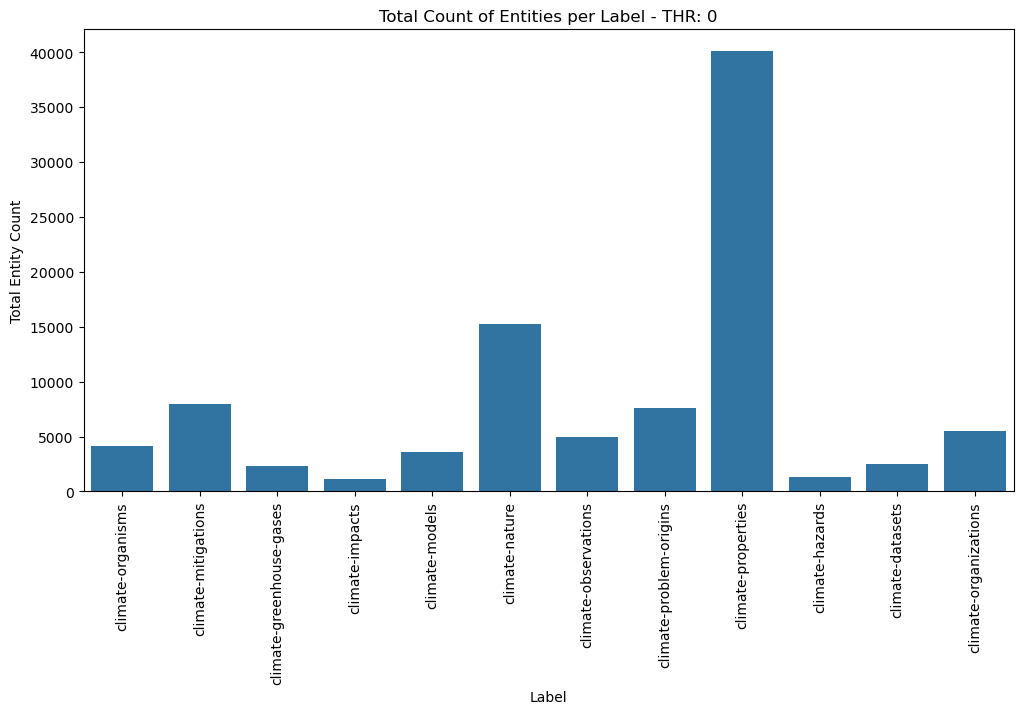

In [23]:
# 00:00:45 for 31093


df = df_og.copy()


# Apply the function to all cells in the DataFrame
df_counts = df.map(list_length)

# Get the total count of entities per label (column)
entity_counts_per_label = df_counts.iloc[:, 3:-1].sum(axis=0)

# # Print statistics about entity counts per label
# print("Entity Counts per Label:")
# print(entity_counts_per_label)

# Plot the distribution of entity counts per label
plt.figure(figsize=(12, 6))
sns.barplot(x=entity_counts_per_label.index, y=entity_counts_per_label.values)
plt.xticks(rotation=90)
plt.title(f"Total Count of Entities per Label - THR: {THR}")

# plt.ylim(0, 3500)


plt.xlabel("Label")
plt.ylabel("Total Entity Count")
output_path = f"./RESULTS/GLINER_TESTS_PLOTS/TCEL_{int(THR*100)}_{len(df_counts)}.png"  # Change to your desired path
plt.savefig(output_path, dpi=300, bbox_inches="tight")  # Save with high resolution and tight layout
plt.show()


#### Frequency distribution of entities for each label (FDEL)

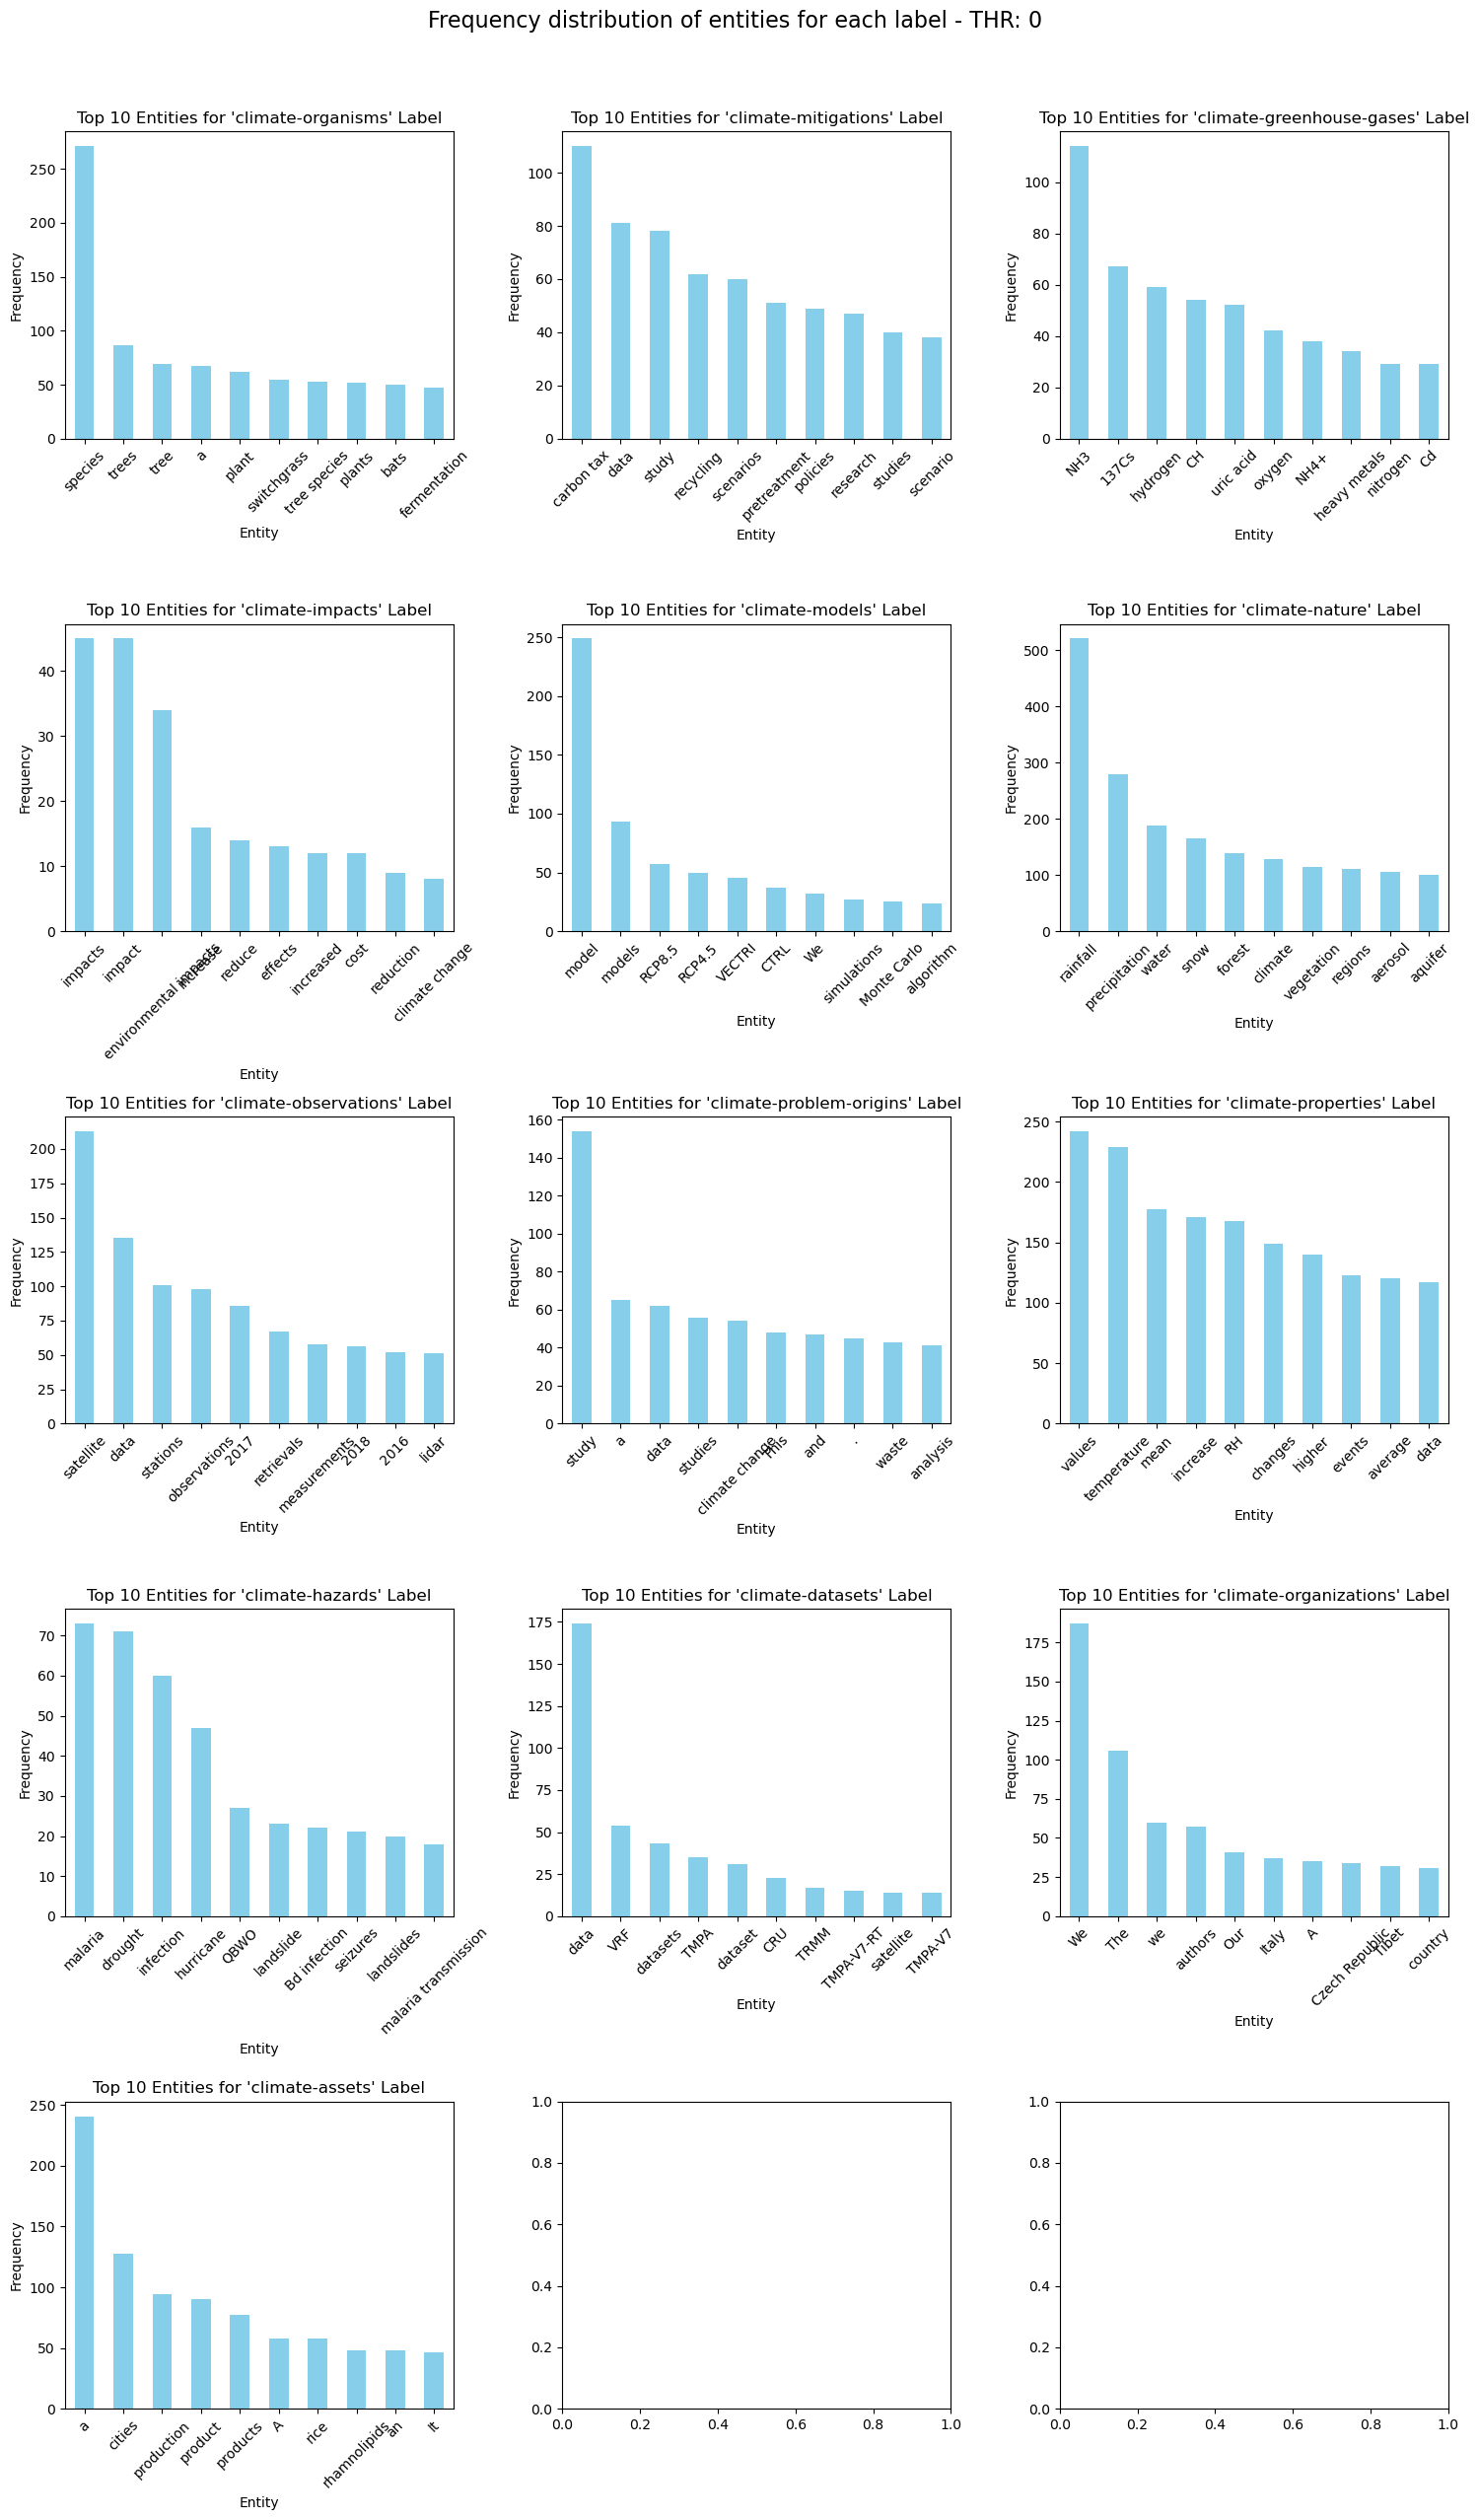

In [24]:
# 00:01:16 for 31093

df = df_og.copy()

# Apply the function to all cells in the DataFrame
df_counts = df.map(list_length)
# Frequency distribution of entities for each label
entity_frequency_per_label = {}

# Iterate over each label column (skipping the first three columns)
for label in df.columns[3:]:  
    all_entities = []
    
    # Check if the entities in the column are lists and flatten them
    for entities in df[label]:
        if isinstance(entities, list):  # Ensure it's a list before iterating
            all_entities.extend(entities)  # Flatten the list of entities
    
    # Create a Series of entity counts for the current label
    entity_frequency_per_label[label] = pd.Series(all_entities).value_counts()

# Set up the number of subplots
num_labels = len(df.columns[3:])

fig, axes = plt.subplots(nrows=(num_labels // 3) + (num_labels % 3 > 0), ncols=3, figsize=(15, 5 * ((num_labels // 3) + 1)))
fig.suptitle(f"Frequency distribution of entities for each label - THR: {THR}", fontsize=16, y=1.02)
# Flatten the axes array for easy iteration
axes = axes.flatten()

# Iterate over each label and its corresponding axis
N = 10
for idx, label in enumerate(df.columns[3:]):
    top_5_entities = entity_frequency_per_label[label].head(N)  # Get top 5 for current label

    # Plot the top 5 frequent entities for the current label
    top_5_entities.plot(kind='bar', ax=axes[idx], color='skyblue')
    
    axes[idx].set_title(f"Top {N} Entities for '{label}' Label")
    axes[idx].set_xlabel("Entity")
    axes[idx].set_ylabel("Frequency")
    axes[idx].tick_params(axis='x', rotation=45)  # Rotate x-axis labels for better readability

# Adjust layout to make sure the subplots fit
plt.tight_layout()

output_path = f"./RESULTS/GLINER_TESTS_PLOTS/FDEL_{int(THR*100)}_{len(df_counts)}.png"  # Change to your desired path
plt.savefig(output_path, dpi=300, bbox_inches="tight")  # Save with high resolution and tight layout
plt.show()


In [25]:
# Convert each Series to a DataFrame, add a column for the category, and concatenate them
df_list = []

for category, series in entity_frequency_per_label.items():
    df = series.reset_index()
    df.columns = ['term', 'count']
    df['category'] = category
    df_list.append(df)

# Concatenate all into a single DataFrame
final_df = pd.concat(df_list, ignore_index=True)

# Optional: reorder columns
final_df = final_df[['category', 'term', 'count']]

# Now `final_df` holds all the data in long-form
print(final_df.head())

            category     term  count
0  climate-organisms  species    271
1  climate-organisms    trees     87
2  climate-organisms     tree     69
3  climate-organisms        a     67
4  climate-organisms    plant     62


In [26]:
final_df.to_csv("efpl_gliner_ibmccner_pure_50sample.csv")

#### Intersection Ratios Between Entity Classes (IRBEC)

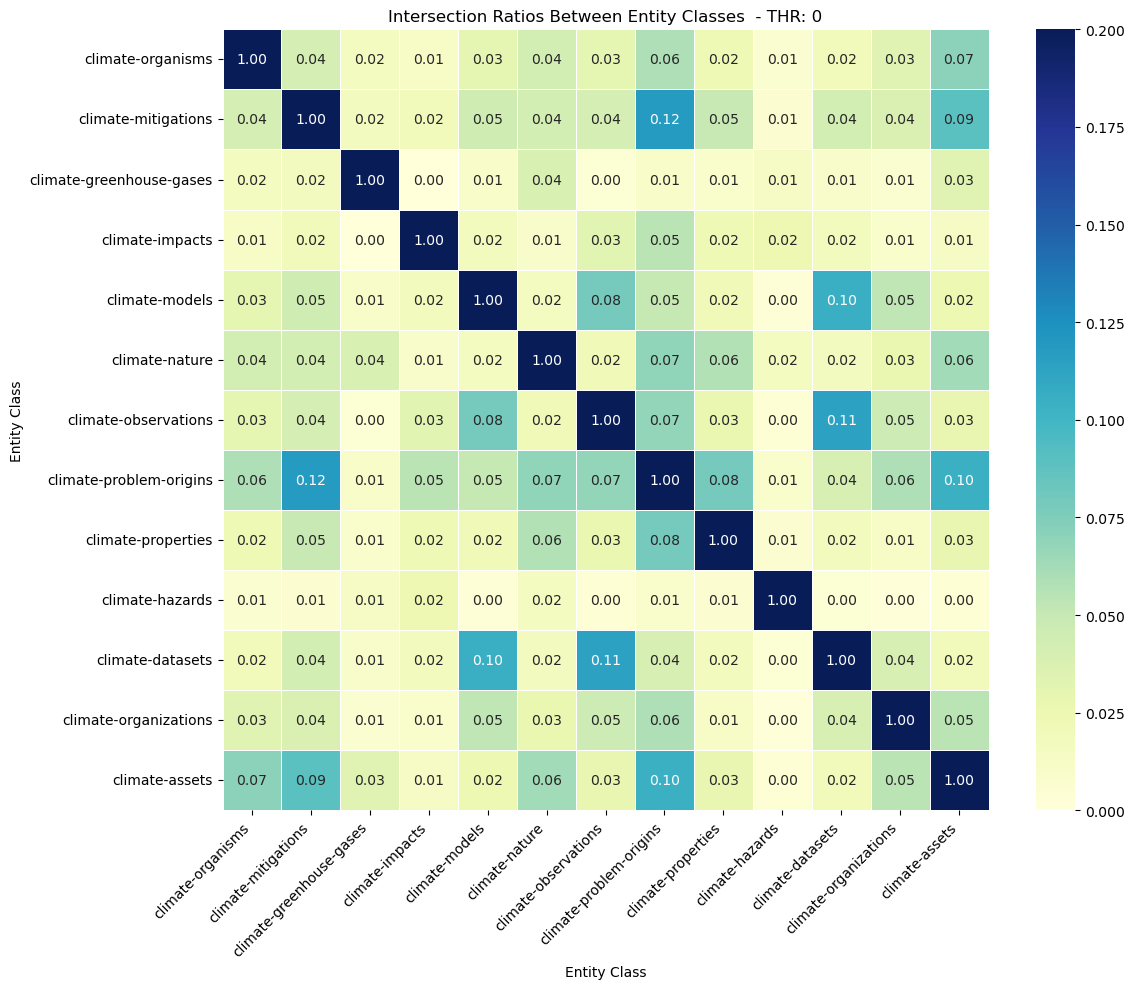

In [27]:
# 00:06:59 for 31093
# 00:14:00 for 32000

from itertools import combinations
import seaborn as sns
import numpy as np

# Step 1: Compute pairwise intersecting ratios

df = df_og.copy()


intersection_ratios = pd.DataFrame(index=labels, columns=labels, dtype=float)

for label1, label2 in combinations(labels, 2):
    entities1 = set([entity for entities in df[label1] if isinstance(entities, list) for entity in entities])
    entities2 = set([entity for entities in df[label2] if isinstance(entities, list) for entity in entities])
    
    # Calculate intersection and union
    intersection = entities1 & entities2
    union = entities1 | entities2
    
    # Compute intersection ratio
    ratio = len(intersection) / len(union) if len(union) > 0 else 0
    intersection_ratios.loc[label1, label2] = ratio
    intersection_ratios.loc[label2, label1] = ratio

# Fill diagonal with 1 (self-comparison)
np.fill_diagonal(intersection_ratios.values, 1)

# Step 2: Visualize the intersecting ratio matrix as a heatmap
plt.figure(figsize=(12, 10))
# sns.heatmap(intersection_ratios, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
sns.heatmap(
    intersection_ratios, 
    annot=True, 
    cmap="YlGnBu",  # Sequential colormap
    fmt=".2f", 
    linewidths=0.5, 
    vmin=0,  # Set the minimum value
    vmax=0.2  # Focus on the 0-0.15 range
)

plt.title(f"Intersection Ratios Between Entity Classes  - THR: {THR}")
plt.xlabel("Entity Class")
plt.ylabel("Entity Class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

output_path = f"./RESULTS/GLINER_TESTS_PLOTS/IRBEC_{int(THR*100)}_{len(df_counts)}.png"  # Change to your desired path
plt.savefig(output_path, dpi=300, bbox_inches="tight")  # Save with high resolution and tight layout
plt.show()


#### Top Labels Across All Sentences


C:\Users\Desktop\AppData\Local\Temp\ipykernel_9256\1485351000.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  label_totals = df.iloc[:, 3:].applymap(len).sum().sort_values(ascending=False)


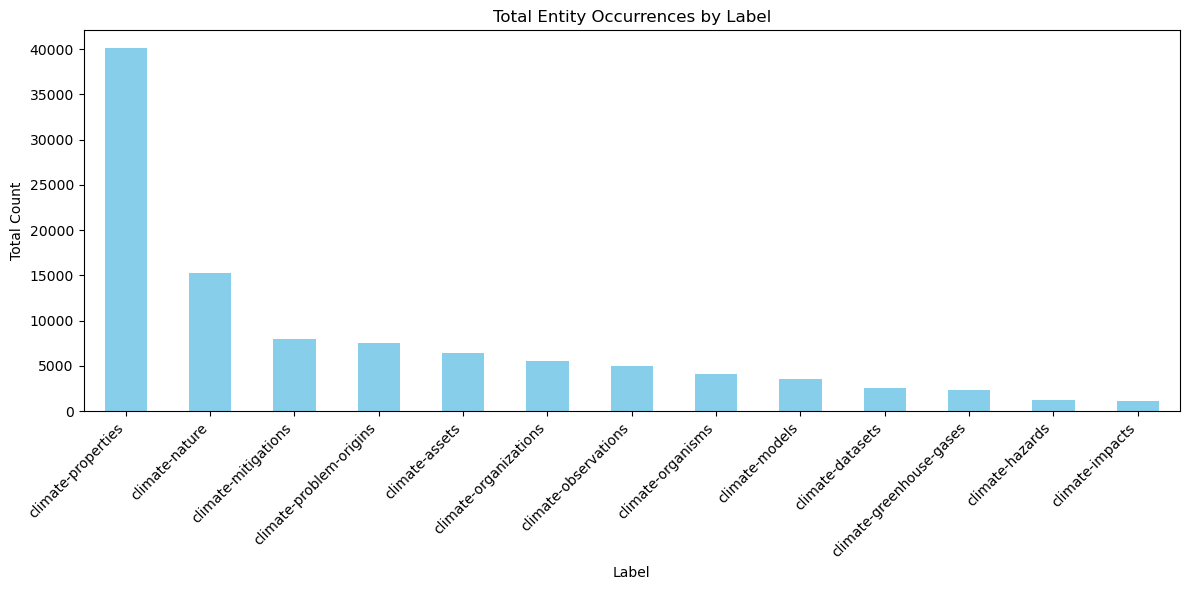

In [28]:
# 00:00:30 for 31093

df = df_og.copy()


# Count the total number of entities for each label
import matplotlib.pyplot as plt
label_totals = df.iloc[:, 3:].applymap(len).sum().sort_values(ascending=False)

# Plot total entity occurrences by label
plt.figure(figsize=(12, 6))
label_totals.plot(kind='bar', color='skyblue')
plt.title("Total Entity Occurrences by Label")
plt.xlabel("Label")
plt.ylabel("Total Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


#### Label Co-Occurrence Heatmap (LCOH)

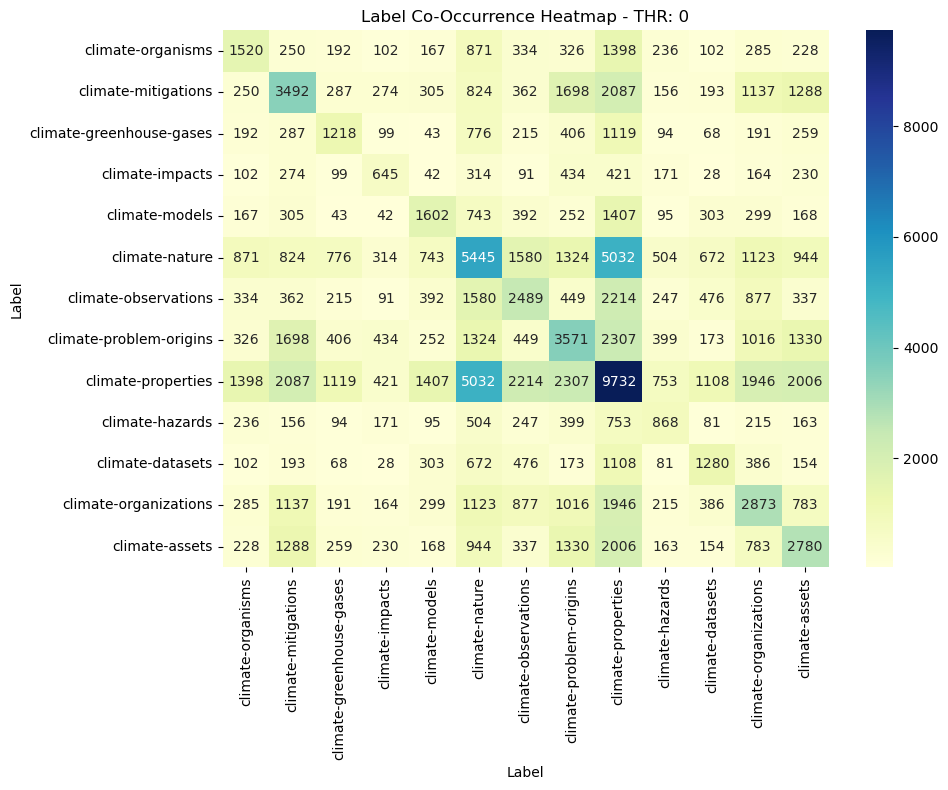

In [29]:
# 01:46:58 for 32k sample
df = df_og.copy()


# Compute co-occurrence matrix
label_columns = df.columns[3:]
co_occurrence = pd.DataFrame(0, index=label_columns, columns=label_columns)

for _, row in df.iterrows():
    active_labels = [label for label in label_columns if len(row[label]) > 0]
    for label1 in active_labels:
        for label2 in active_labels:
            co_occurrence.loc[label1, label2] += 1

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(co_occurrence, annot=True, fmt='d', cmap='YlGnBu')
plt.title(f"Label Co-Occurrence Heatmap - THR: {THR}")
plt.xlabel("Label")
plt.ylabel("Label")
plt.tight_layout()
output_path = f"./RESULTS/GLINER_TESTS_PLOTS/LCOH_{int(THR*100)}_{len(df_counts)}.png"  # Change to your desired path
plt.savefig(output_path, dpi=300, bbox_inches="tight")  # Save with high resolution and tight layout

plt.show()


#### Sentence Diversity by Number of Labels

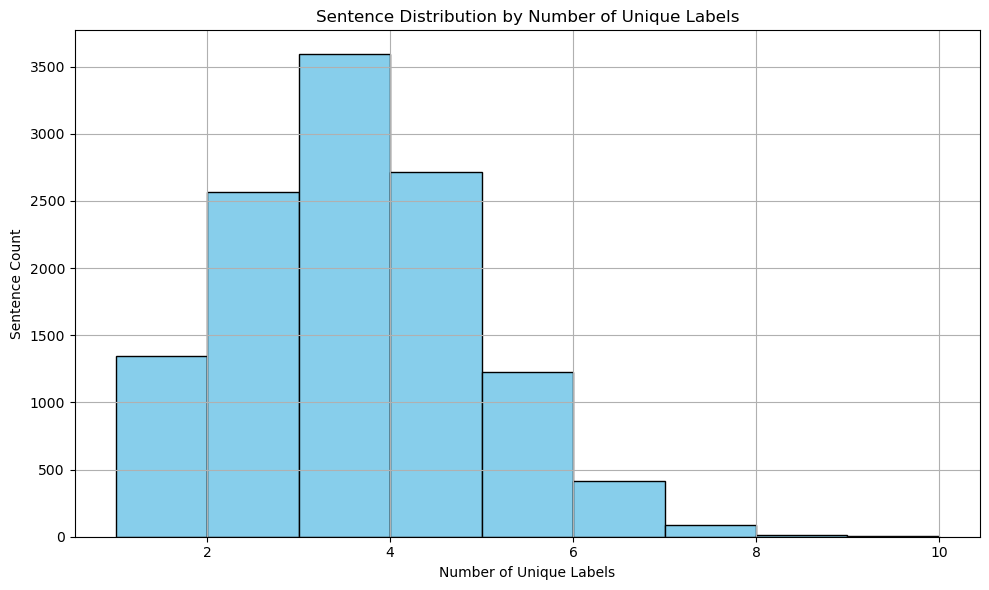

In [30]:
# 00:01:16 for 31093

df = df_og.copy()

# Count the number of unique labels per sentence
sentence_label_count = df.iloc[:, 3:].map(len).gt(0).sum(axis=1)

# Plot histogram
plt.figure(figsize=(10, 6))
sentence_label_count.hist(bins=range(1, sentence_label_count.max() + 2), color='skyblue', edgecolor='black')
plt.title("Sentence Distribution by Number of Unique Labels")
plt.xlabel("Number of Unique Labels")
plt.ylabel("Sentence Count")
plt.tight_layout()
plt.show()

#### Entity Coverage Across Sentences

C:\Users\Desktop\AppData\Local\Temp\ipykernel_9256\3046765688.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  coverage = df.iloc[:, 3:].applymap(len).gt(0).mean().sort_values(ascending=False) * 100


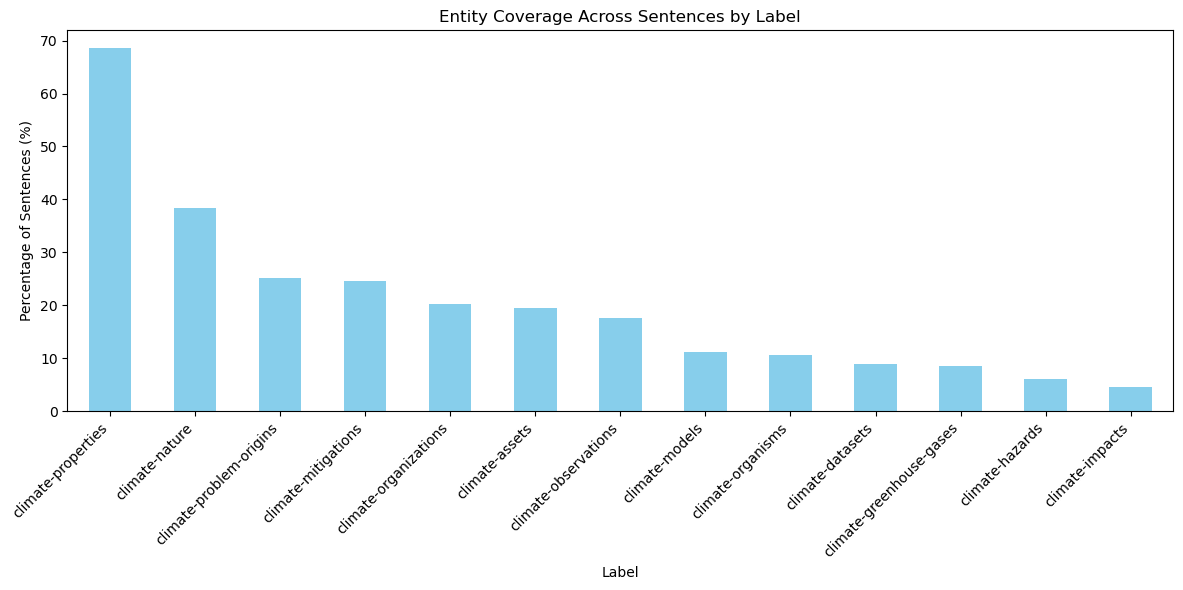

In [31]:
df = df_og.copy()

# Compute the percentage of sentences containing each label
coverage = df.iloc[:, 3:].applymap(len).gt(0).mean().sort_values(ascending=False) * 100

# Plot coverage
plt.figure(figsize=(12, 6))
coverage.plot(kind='bar', color='skyblue')
plt.title("Entity Coverage Across Sentences by Label")
plt.xlabel("Label")
plt.ylabel("Percentage of Sentences (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


#### Entity Proportions by Label

C:\Users\Desktop\AppData\Local\Temp\ipykernel_9256\1166484711.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  total_entities = df.iloc[:, 3:].applymap(len).sum()


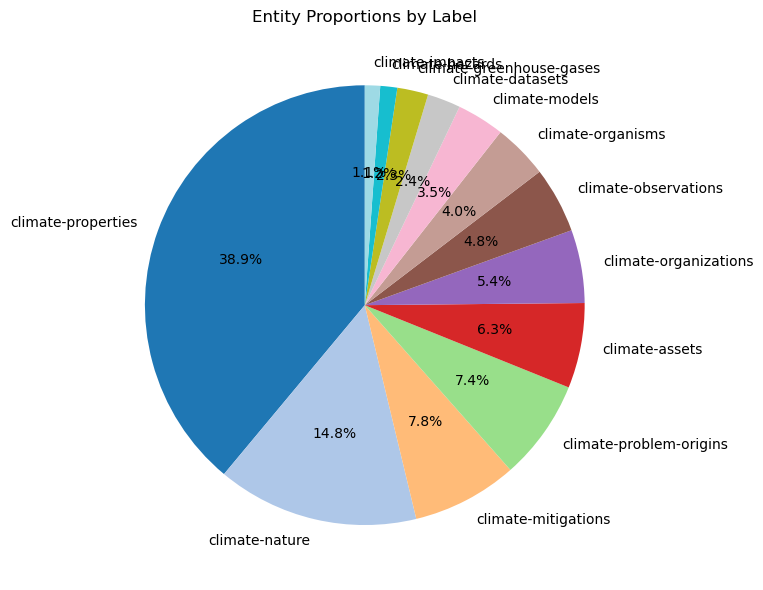

In [32]:
df = df_og.copy()

# Calculate the total number of entities for each label
total_entities = df.iloc[:, 3:].applymap(len).sum()
total_entities_all = total_entities.sum()

# Compute proportions
proportions = (total_entities / total_entities_all) * 100

# Plot proportions
plt.figure(figsize=(12, 6))
proportions.sort_values(ascending=False).plot(kind='pie', autopct='%1.1f%%', startangle=90, cmap='tab20')
plt.title("Entity Proportions by Label")
plt.ylabel("")  # Remove the y-axis label for better aesthetics
plt.tight_layout()
plt.show()


#### Top Overlapping Labels in Sentences

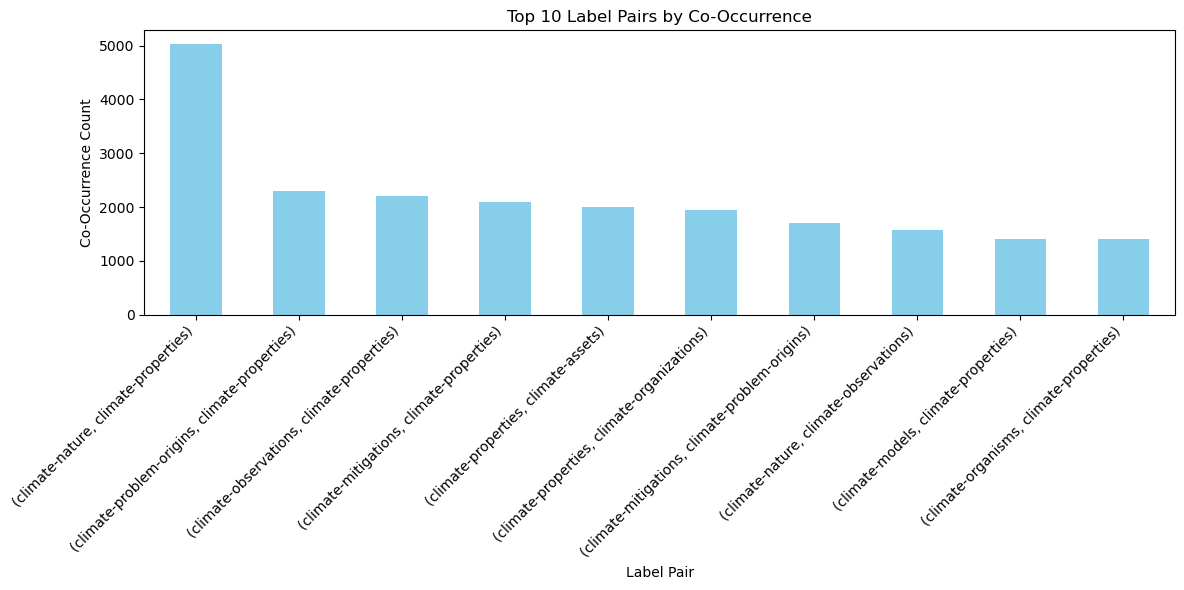

In [33]:
# 00:08:23 for 32k sample
df = df_og.copy()

# Compute co-occurrence counts for pairs of labels
from itertools import combinations
co_occurrence_pairs = {}

for _, row in df.iterrows():
    active_labels = [label for label in df.columns[3:] if len(row[label]) > 0]
    for pair in combinations(active_labels, 2):
        co_occurrence_pairs[pair] = co_occurrence_pairs.get(pair, 0) + 1

# Convert to a sorted Series for easy plotting
co_occurrence_series = pd.Series(co_occurrence_pairs).sort_values(ascending=False)

# Plot the top overlapping pairs
top_n = 10  # Change this to visualize more or fewer pairs
plt.figure(figsize=(12, 6))
co_occurrence_series.head(top_n).plot(kind='bar', color='skyblue')
plt.title(f"Top {top_n} Label Pairs by Co-Occurrence")
plt.xlabel("Label Pair")
plt.ylabel("Co-Occurrence Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


#### Word Count vs. Number of Entities

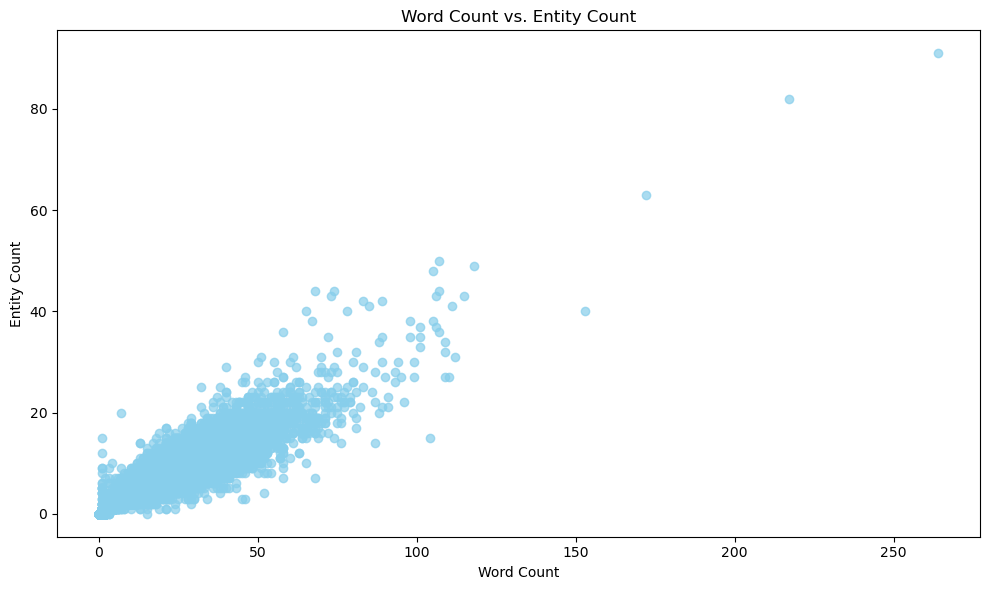

Correlation between word count and entity count: 0.91


In [34]:
df = df_og.copy()

# Calculate word count and entity count per sentence
df['word_count'] = df['sentence'].str.split().str.len()
df['entity_count'] = df.iloc[:, 3:-1].map(len).sum(axis=1)
# print(df.iloc[:, 3:-1])
# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df['word_count'], df['entity_count'], alpha=0.7, color='skyblue')
plt.title("Word Count vs. Entity Count")
plt.xlabel("Word Count")
plt.ylabel("Entity Count")
plt.tight_layout()
plt.show()

# Optional: Calculate correlation
correlation = df[['word_count', 'entity_count']].corr().iloc[0, 1]
print(f"Correlation between word count and entity count: {correlation:.2f}")


#### Label Importance via TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

df = df_og.copy()


# Concatenate all entity texts per label
label_texts = {label: ' '.join([entity for entities in df[label] for entity in entities if isinstance(entities, list)]) 
               for label in df.columns[3:-2]}

# Calculate TF-IDF
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(label_texts.values())
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), index=label_texts.keys(), columns=vectorizer.get_feature_names_out())

# Plot heatmap of TF-IDF scores
plt.figure(figsize=(12, 8))
sns.heatmap(tfidf_df.T, cmap='viridis', annot=False)
plt.title("TF-IDF Heatmap of Entity Terms Across Labels")
plt.xlabel("Label")
plt.ylabel("Terms")
plt.tight_layout()
plt.show()


#### Wordcloud

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

df = df_og.copy()


# Create a grid for the subplots
num_labels = len(df.columns[3:-2])  # Number of labels
cols = 3  # Number of columns in the grid
rows = (num_labels // cols) + (num_labels % cols > 0)  # Calculate rows based on labels

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()  # Flatten the axes array for easy iteration

# Generate word cloud for each label
for idx, label in enumerate(df.columns[3:-2]):
    all_entities = ' '.join([entity for entities in df[label] for entity in entities if isinstance(entities, list)])
    
    if all_entities:  # Check if the label has entities
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_entities)
        axes[idx].imshow(wordcloud, interpolation='bilinear')
        axes[idx].axis("off")
        axes[idx].set_title(f"'{label}' Entities")
    else:
        axes[idx].axis("off")
        axes[idx].set_title(f"'{label}' Entities (No Data)")

# Remove unused subplots
for ax in axes[num_labels:]:
    ax.axis("off")

# Adjust layout and add an overall title
plt.tight_layout()
fig.suptitle("Word Clouds for All Entity Labels", fontsize=16, y=1.02)
plt.subplots_adjust(top=0.92)
plt.show()


## 5) Conclusion

In [35]:

for paper in tqdm(test_papers):
    # Load sentences from the paper
    test_paper_sentences = load_paper_sentences(paper, PAPER_DIR)
    
    for text in test_paper_sentences:
        print()
        print("Sentence: ", text)
        
        # Perform entity prediction
        entities = model.predict_entities(text, labels, threshold=0.5)
        
        # Sort entities by score in descending order
        sorted_entities = sorted(entities, key=lambda x: x['score'], reverse=True)
        
        # Display predicted entities, their labels, and scores
        for entity in sorted_entities:
            print(f"{entity['text']}", f"\t|| {entity['label']}", f"\t|| {entity['score']:.2f}")
        
        
        print("---" * 10)

  0%|          | 0/50 [00:00<?, ?it/s]


Sentence:  This study aims to investigate the effect of Na doping on the structure, electrical, and electrochemical properties of lithium-rich cathode material.
electrochemical properties 	|| climate-properties 	|| 0.53
Na 	|| climate-greenhouse-gases 	|| 0.52
electrical 	|| climate-properties 	|| 0.51
lithium-rich 	|| climate-greenhouse-gases 	|| 0.50
------------------------------

Sentence:  Pristine Li1.2Ni0.13Mn0.54Co0.13O2 (LNMC) and Na-doped Li1.17Na0.03Ni0.13Mn0.54Co0.13O2 (Na-LNMC) layered lithium-rich/manganese-rich compounds are prepared by the sol-gel method.
Na-LNMC 	|| climate-nature 	|| 0.51
------------------------------

Sentence:  The structural and morphological characterization reveals that the Na doping leads to an ordered structure with regular cubic morphology and enlarged Li layer spacing.
Li layer spacing 	|| climate-properties 	|| 0.63
Na doping 	|| climate-properties 	|| 0.53
morphology 	|| climate-properties 	|| 0.52
ordered structure 	|| climate-properties

  0%|          | 0/50 [00:03<?, ?it/s]


KeyboardInterrupt: 

## 6) Extra comparisons

In [ ]:
# Functions
from os import listdir

RESULT_DIR_1 = "./RESULTS/GLINER_TESTS/" # "./RESULTS/GLINER_TESTS/" # PC2
RESULT_DIR_2 = "./RESULTS/GLINER_TESTS_10/" # "./RESULTS/GLINER_TESTS/" # PC2


test_files_1 = listdir(RESULT_DIR_1)
test_files_2 = listdir(RESULT_DIR_2)

In [ ]:
import pandas as pd

columns = ["paper_id", "sentence_id", "sentence"]
columns.extend(labels)
print(columns)
import pandas as pd

def process_data_to_dataframe(test_files, labels, THR, results_dir=RESULT_DIR):
    # Define the columns for the DataFrame
    columns = ["paper_id", "sentence_id", "sentence"]
    columns.extend(labels)  # Add the entity labels to the columns

    # Initialize the list to store rows
    rows = []

    # Process each test file
    for test_file in test_files:
        # Assuming json2dict is defined elsewhere and returns (data_p, thr_p, title_p)
        data_p, thr_p, title_p = json2dict(test_file, results_dir)
        
        # Extract paper_id from title
        paper_id = title_p.split("_")[0]

        # Process each item in the JSON data
        for item in data_p:
            sentence_id = item["sentence_id"]
            sentence = item["sentence"]

            # Initialize a row with empty lists for entity occurrences
            row = {col: [] for col in columns}
            row['paper_id'] = paper_id
            row['sentence_id'] = sentence_id
            row['sentence'] = sentence

            # Collect occurrences of each entity label
            for entity in item.get("entities", []):
                if isinstance(entity, dict) and entity.get("score", 0) >= THR:
                    label = entity["label"]
                    if label in row:
                        row[label].append(entity["text"])  # Add the entity's text to the list
            
            # Append the row to the list of rows
            rows.append(row)

    # Create and return the DataFrame
    df_og = pd.DataFrame(rows, columns=columns)
    return df_og

# Create the DataFrame
df_og_1 = process_data_to_dataframe(test_files_1, labels, THR, RESULT_DIR_1)
df_og_2 = process_data_to_dataframe(test_files_2, labels, THR, RESULT_DIR_2)


# Define a function to calculate the length of a list
def list_length(cell):
    if isinstance(cell, list):  # Ensure we only process lists
        return len(cell)
    return cell  # Return the cell as-is if it's not a list

# Apply the function to all cells in the DataFrame
df_counts_1 = df_og_1.map(list_length)
df_counts_2 = df_og_2.map(list_length)



In [ ]:
# Apply the function to all cells in the DataFrame
df_counts_1 = df_og_1.map(list_length)
df_counts_2 = df_og_2.map(list_length)

# Get the total count of entities per label (column)
entity_counts_per_label_1 = df_counts_1.iloc[:, 3:-1].sum(axis=0)
entity_counts_per_label_2 = df_counts_2.iloc[:, 3:-1].sum(axis=0)

#### Distribution overlap

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=entity_counts_per_label_1.index, y=entity_counts_per_label_1.values, label="Distribution 1", marker="o")
sns.lineplot(x=entity_counts_per_label_2.index, y=entity_counts_per_label_2.values, label="Distribution 2", marker="o")
plt.xticks(rotation=90)
plt.title(f"Comparison of Entity Counts per Label - THR: {THR}")
plt.xlabel("Label")
plt.ylabel("Total Entity Count")
plt.legend()
plt.show()

#### Correlation Coefficient (Pearson/Spearman)

In [ ]:
from scipy.stats import pearsonr, spearmanr

# Ensure both distributions are aligned and have the same labels
common_labels = entity_counts_per_label_1.index.intersection(entity_counts_per_label_2.index)

dist1 = entity_counts_per_label_1[common_labels]
dist2 = entity_counts_per_label_2[common_labels]

pearson_corr, _ = pearsonr(dist1, dist2)
spearman_corr, _ = spearmanr(dist1, dist2)

print(f"Pearson Correlation: {pearson_corr:.3f}")
print(f"Spearman Correlation: {spearman_corr:.3f}")

#### Kolmogorov-Smirnov (KS) Test

In [ ]:
from scipy.stats import ks_2samp

ks_stat, p_value = ks_2samp(dist1, dist2)
print(f"KS Statistic: {ks_stat:.3f}, p-value: {p_value:.3f}")


#### Jensen-Shannon Divergence

In [ ]:
from scipy.spatial.distance import jensenshannon
import numpy as np

# Convert counts to probability distributions
dist1_prob = dist1 / np.sum(dist1)
dist2_prob = dist2 / np.sum(dist2)

js_divergence = jensenshannon(dist1_prob, dist2_prob)
print(f"Jensen-Shannon Divergence: {js_divergence:.3f}")


#### Distribution overlap 2

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Convert to DataFrame for easier processing
df_norm = pd.DataFrame({
    "Label": entity_counts_per_label_1.index,
    "Distribution 1": entity_counts_per_label_1.values,
    "Distribution 2": entity_counts_per_label_2.reindex(entity_counts_per_label_1.index, fill_value=0).values  # Align indexes
})

# Apply Min-Max Scaling
scaler = MinMaxScaler()
df_norm[["Distribution 1", "Distribution 2"]] = scaler.fit_transform(df_norm[["Distribution 1", "Distribution 2"]])

# Plot normalized distributions
plt.figure(figsize=(12, 6))
sns.lineplot(x=df_norm["Label"], y=df_norm["Distribution 1"], label="Distribution 1 (Normalized)", marker="o")
sns.lineplot(x=df_norm["Label"], y=df_norm["Distribution 2"], label="Distribution 2 (Normalized)", marker="o")
plt.xticks(rotation=90)
plt.title(f"Comparison of Normalized Entity Counts per Label - THR: {THR}")
plt.xlabel("Label")
plt.ylabel("Normalized Entity Count")
plt.legend()
plt.show()
